# 09 - Pipeline Final e Salvamento

Aqui eu fecho o modelo:

- treino a versão final com todo o treino;
- avalio uma única vez no teste, que até agora não foi usado para nenhuma
  decisão;
- salvo o pipeline completo em disco, junto com o limiar e as métricas;
- mostro como fazer uma previsão para uma reserva nova (o que o app usa).

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import json
import warnings
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier

from src.preprocessing import (preparar, separar_treino_teste,
                               VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
LIMIAR = 0.40   # notebook 06

In [2]:
df = preparar()
treino, teste = separar_treino_teste(df)
variaveis = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS

X_treino, y_treino = treino[variaveis], treino[ALVO]
X_teste, y_teste = teste[variaveis], teste[ALVO]
print("treino:", len(treino), " teste:", len(teste))

treino: 95367  teste: 23842


## 2. Treino da versão final

Uso a configuração do notebook 06: XGBoost com os hiperparâmetros escolhidos.
A busca de hiperparâmetros trouxe ganho pequeno e a calibração extra não
ajudou, então o modelo final é o próprio XGBoost.

In [3]:
preproc = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])

peso_pos = (y_treino == 0).sum() / (y_treino == 1).sum()
modelo_final = Pipeline([
    ("prep", preproc),
    ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.9,
                          scale_pos_weight=peso_pos, eval_metric="logloss",
                          random_state=42, n_jobs=4)),
])
modelo_final.fit(X_treino, y_treino)

,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 3. Avaliação final no teste

In [4]:
prob_teste = modelo_final.predict_proba(X_teste)[:, 1]
pred_teste = (prob_teste >= LIMIAR).astype(int)

resultado = {
    "accuracy": accuracy_score(y_teste, pred_teste),
    "precision": precision_score(y_teste, pred_teste),
    "recall": recall_score(y_teste, pred_teste),
    "f1": f1_score(y_teste, pred_teste),
    "roc_auc": roc_auc_score(y_teste, prob_teste),
    "pr_auc": average_precision_score(y_teste, prob_teste),
    "brier": brier_score_loss(y_teste, prob_teste),
}
pd.Series(resultado).round(3)

accuracy    0.795
precision   0.735
recall      0.778
f1          0.756
roc_auc     0.889
pr_auc      0.847
brier       0.135
dtype: float64

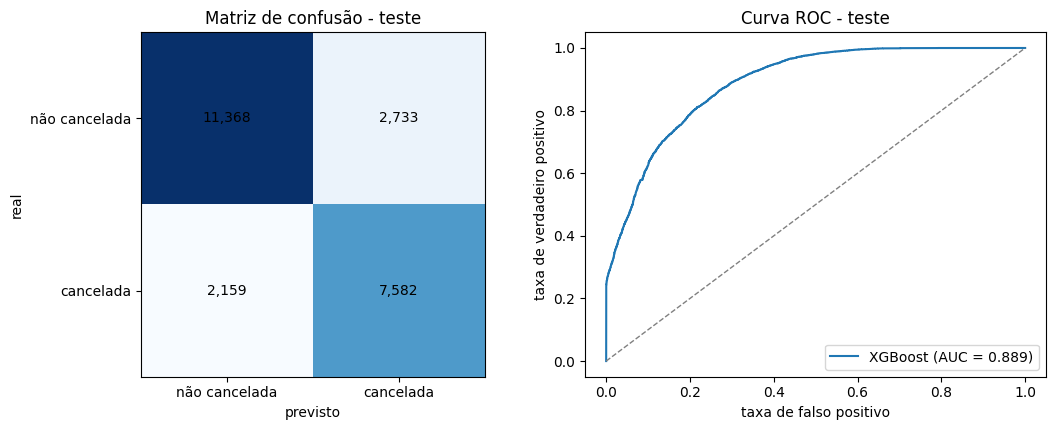

In [5]:
cm = confusion_matrix(y_teste, pred_teste)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

ax[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, f"{v:,}", ha="center", va="center")
ax[0].set_xticks([0, 1], ["não cancelada", "cancelada"])
ax[0].set_yticks([0, 1], ["não cancelada", "cancelada"])
ax[0].set_xlabel("previsto")
ax[0].set_ylabel("real")
ax[0].set_title("Matriz de confusão - teste")

fpr, tpr, _ = roc_curve(y_teste, prob_teste)
ax[1].plot(fpr, tpr, label=f"XGBoost (AUC = {resultado['roc_auc']:.3f})")
ax[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax[1].set_xlabel("taxa de falso positivo")
ax[1].set_ylabel("taxa de verdadeiro positivo")
ax[1].set_title("Curva ROC - teste")
ax[1].legend()
plt.tight_layout()
plt.show()

In [6]:
# guarda a figura para o README (sobe uma pasta, entra em reports/figures)
fig.savefig("../reports/figures/avaliacao_teste.png")

Esses são os números que reporto no relatório. A avaliação foi feita uma
única vez, no período mais recente, com o modelo treinado só com dados
anteriores.

## 4. Salvamento

In [7]:
from pathlib import Path

pasta = Path("../models")
pasta.mkdir(exist_ok=True)

joblib.dump(modelo_final, pasta / "final_pipeline.joblib")

config = {
    "modelo": "XGBoost",
    "limiar": LIMIAR,
    "variaveis": variaveis,
    "treinado_em": str(date.today()),
    "metricas_teste": {k: round(float(v), 4) for k, v in resultado.items()},
}
(pasta / "final_config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False))
config

{'modelo': 'XGBoost',
 'limiar': 0.4,
 'variaveis': ['lead_time',
  'arrival_date_week_number',
  'arrival_date_day_of_month',
  'stays_in_weekend_nights',
  'stays_in_week_nights',
  'adults',
  'children',
  'babies',
  'is_repeated_guest',
  'previous_cancellations',
  'previous_bookings_not_canceled',
  'required_car_parking_spaces',
  'total_of_special_requests',
  'adr',
  'total_nights',
  'total_guests',
  'has_previous_cancellation',
  'zero_nights',
  'has_company',
  'has_agent',
  'hotel',
  'arrival_date_month',
  'meal',
  'country',
  'market_segment',
  'distribution_channel',
  'reserved_room_type',
  'deposit_type',
  'customer_type',
  'agent',
  'arrival_dow',
  'booking_month',
  'booking_dow'],
 'treinado_em': '2026-09-02',
 'metricas_teste': {'accuracy': 0.7948,
  'precision': 0.735,
  'recall': 0.7784,
  'f1': 0.7561,
  'roc_auc': 0.8886,
  'pr_auc': 0.8471,
  'brier': 0.1354}}

In [8]:
# mesma versão do modelo, guardada à parte só para o app explicar as previsões
joblib.dump(modelo_final, pasta / "explainer.joblib")

['..\\models\\explainer.joblib']

## 5. Previsão para uma reserva nova

In [9]:
def faixa(prob):
    if prob >= 0.6:
        return "alto"
    if prob >= LIMIAR:
        return "médio"
    return "baixo"

exemplo = teste.iloc[[5, 200, 900]][variaveis].copy()
prob_exemplo = modelo_final.predict_proba(exemplo)[:, 1]

saida = exemplo[["hotel", "lead_time", "deposit_type", "market_segment", "adr", "total_nights"]].copy()
saida["prob_cancelamento"] = prob_exemplo.round(3)
saida["faixa"] = [faixa(p) for p in prob_exemplo]
saida["exposicao"] = (prob_exemplo * exemplo["adr"] * exemplo["total_nights"]).round(0)
saida

,hotel,lead_time,deposit_type,market_segment,adr,total_nights,prob_cancelamento,faixa,exposicao
5,City Hotel,96,No Deposit,Online TA,126.000,3,0.542,médio,205.000
200,City Hotel,18,Non Refund,Direct,102.600,1,0.999,alto,102.000
900,Resort Hotel,1,No Deposit,Online TA,71.000,1,0.000,baixo,0.000


In [10]:
recarregado = joblib.load(pasta / "final_pipeline.joblib")
np.allclose(recarregado.predict_proba(X_teste)[:, 1], prob_teste)

True

## 6. Limitações e próximos passos

Limitações:

- os dados vão só até agosto de 2017 e são de dois hotéis de Portugal;
- não há um identificador de reserva, o que obrigou a decisões conservadoras
  com as linhas repetidas;
- algumas variáveis foram deixadas de fora para evitar data leakage;
- o modelo estima a probabilidade de cancelamento, não recomenda uma ação.

Próximos passos:

- reavaliar o modelo com dados mais recentes antes de usar;
- testar uma variável de taxa histórica de cancelamento por agência ou país,
  calculada só com dados passados;
- acompanhar a calibração ao longo do tempo.

## 7. O que fica pronto

- `models/final_pipeline.joblib`: pipeline completo (pré-processamento + XGBoost);
- `models/final_config.json`: limiar e métricas de teste;
- o notebook 10 faz uma análise de agrupamento das reservas, e o app usa o
  pipeline salvo para pontuar uma reserva nova.